### NK cell Gene Set Enrichment Analysis
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Hallmark pathway enrichment from NK pseudobulk DESeq2 results*

#### Aim
This notebook performs gene set enrichment analysis using age-associated DESeq2 results from NK cell pseudobulk analysis.

Genes are ranked by the DESeq2 test statistic for each NK subset, and preranked GSEA is performed using Hallmark gene sets to identify pathways enriched with increasing or decreasing age.

*Note: This notebook uses DESeq2 output files generated in the previous differential expression notebook. It does not perform differential expression testing directly.*

In [17]:
import gseapy as gp
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

deg_dir = Path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk")
outdir = Path("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_GSEA/nk")
outdir.mkdir(exist_ok=True)

deg_files = {
    "CD56_bright_CD16-_NK": deg_dir / "DESeq2_age_CD56_bright_CD16-_NK.csv",
    "CD56_dim_CD16__KLRC2__NK": deg_dir / "DESeq2_age_CD56_dim_CD16__KLRC2__NK.csv",
    "CD56_dim_CD16__NK": deg_dir / "DESeq2_age_CD56_dim_CD16__NK.csv"
}

## GSEA

In [ ]:
# Define function to run preranked GSEA
def run_gsea(celltype_name, deg_file):
    
    print(f"Running GSEA for {celltype_name}")
    
    # Load DESeq2 result table
    res = pd.read_csv(deg_file)
    
    # Retain genes with available DESeq2 test statistics
    res = res.dropna(subset=["gene", "stat"])
    
    # Remove duplicated gene entries before ranking
    res = res.drop_duplicates(subset="gene")
    
    # Rank genes by DESeq2 test statistic
    ranking = res[["gene", "stat"]].copy()
    ranking = ranking.sort_values("stat", ascending=False)
    
    # Output folder
    ct_outdir = outdir / celltype_name
    ct_outdir.mkdir(exist_ok=True)
    
    # Run preranked GSEA using Hallmark gene sets
    pre_res = gp.prerank(
        rnk=ranking,
        gene_sets="MSigDB_Hallmark_2020",
        outdir=str(ct_outdir),
        permutation_num=1000,
        seed=42,
        min_size=15,
        max_size=500,
        verbose=True
    )
    
    # Save result table
    gsea_df = pre_res.res2d
    gsea_df.to_csv(ct_outdir / f"GSEA_Hallmark_{celltype_name}.csv")
    
    return gsea_df

In [ ]:
# Run preranked GSEA for each subset with an available DESeq2 result file
all_gsea = {}

for ct, file in deg_files.items():
    if file.exists():
        all_gsea[ct] = run_gsea(ct, file)
    else:
        print(f"Missing file for {ct}: {file}")

2026-05-18 16:37:46,305 [INFO] Parsing data files for GSEA.............................
2026-05-18 16:37:46,310 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-18 16:37:46,314 [INFO] 0005 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-18 16:37:46,315 [INFO] 0045 gene_sets used for further statistical testing.....
2026-05-18 16:37:46,315 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD56_bright_CD16-_NK


2026-05-18 16:37:49,773 [INFO] Congratulations. GSEApy runs successfully................

2026-05-18 16:37:49,799 [INFO] Parsing data files for GSEA.............................
2026-05-18 16:37:49,810 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-18 16:37:49,815 [INFO] 0002 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-18 16:37:49,815 [INFO] 0048 gene_sets used for further statistical testing.....
2026-05-18 16:37:49,815 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD56_dim_CD16__KLRC2__NK


2026-05-18 16:37:55,072 [INFO] Congratulations. GSEApy runs successfully................

2026-05-18 16:37:55,117 [INFO] Parsing data files for GSEA.............................
2026-05-18 16:37:55,131 [INFO] Enrichr library gene sets already downloaded in: /home/s4575250/.cache/gseapy, use local file
2026-05-18 16:37:55,136 [INFO] 0001 gene_sets have been filtered out when max_size=500 and min_size=15
2026-05-18 16:37:55,137 [INFO] 0049 gene_sets used for further statistical testing.....
2026-05-18 16:37:55,137 [INFO] Start to run GSEA...Might take a while..................


Running GSEA for CD56_dim_CD16__NK


2026-05-18 16:38:04,321 [INFO] Congratulations. GSEApy runs successfully................



In [20]:
# Combine GSEA results
combined = []

for ct, df in all_gsea.items():
    temp = df.copy()
    temp["cell_type"] = ct
    combined.append(temp)

gsea_combined = pd.concat(combined, axis=0)

gsea_combined.to_csv(outdir / "NK_GSEA_Hallmark_combined.csv", index=False)

gsea_combined.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type
0,prerank,Interferon Alpha Response,-0.492094,-1.937487,0.0,0.003239,0.003,31/68,23.41%,TXNIP;TRIM25;IRF9;UBE2L6;CD47;RIPK2;ISG20;PARP...,CD56_bright_CD16-_NK
1,prerank,TGF-beta Signaling,0.464507,1.681994,0.016055,0.074107,0.081,8/33,6.44%,SPTBN1;BMPR1A;PPM1A;CTNNB1;SMAD3;UBE2D3;SKIL;S...,CD56_bright_CD16-_NK
2,prerank,Allograft Rejection,-0.382631,-1.66395,0.001603,0.06585,0.114,22/111,8.96%,KLRD1;GPR65;ETS1;SRGN;PRKCB;GZMB;CD47;CCL4;RIP...,CD56_bright_CD16-_NK
3,prerank,TNF-alpha Signaling via NF-kB,0.367603,1.652763,0.0,0.047199,0.102,25/93,7.30%,JUN;FOS;SLC2A3;SQSTM1;REL;KLF6;NR4A3;RELB;NR4A...,CD56_bright_CD16-_NK
4,prerank,KRAS Signaling Up,-0.409828,-1.604572,0.003442,0.079884,0.196,25/64,24.88%,IKZF1;PRDM1;ETS1;ID2;CBR4;DNMBP;GLRX;CBL;IRF8;...,CD56_bright_CD16-_NK


### Significant GSEA pathways

In [21]:
gsea_combined.columns

Index(['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val',
       'Tag %', 'Gene %', 'Lead_genes', 'cell_type'],
      dtype='object')

In [ ]:
# Retain pathways passing the FDR threshold
sig_gsea = gsea_combined[
    gsea_combined["FDR q-val"] < 0.05
].copy()

# Sort significant pathways by cell type and FDR
sig_gsea = sig_gsea.sort_values(
    ["cell_type", "FDR q-val"]
)

sig_gsea.to_csv(
    outdir / "NK_GSEA_Hallmark_significant.csv",
    index=False
)

sig_gsea.head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,cell_type
0,prerank,Interferon Alpha Response,-0.492094,-1.937487,0.0,0.003239,0.003,31/68,23.41%,TXNIP;TRIM25;IRF9;UBE2L6;CD47;RIPK2;ISG20;PARP...,CD56_bright_CD16-_NK
3,prerank,TNF-alpha Signaling via NF-kB,0.367603,1.652763,0.0,0.047199,0.102,25/93,7.30%,JUN;FOS;SLC2A3;SQSTM1;REL;KLF6;NR4A3;RELB;NR4A...,CD56_bright_CD16-_NK
0,prerank,Interferon Gamma Response,-0.593926,-3.018948,0.0,0.0,0.0,86/174,14.08%,CD38;UBE2L6;ISG15;IFI44L;LY6E;LGALS3BP;MX1;IRF...,CD56_dim_CD16__KLRC2__NK
1,prerank,Interferon Alpha Response,-0.636075,-2.888511,0.0,0.0,0.0,53/91,14.57%,UBE2L6;ISG15;IFI44L;PARP9;LY6E;LGALS3BP;MX1;IR...,CD56_dim_CD16__KLRC2__NK
2,prerank,Oxidative Phosphorylation,-0.3982,-2.073569,0.0,0.001329,0.002,80/198,23.48%,NDUFB4;NDUFA3;HADHB;ATP5MC2;COX6B1;IDH2;NDUFS7...,CD56_dim_CD16__KLRC2__NK
3,prerank,Allograft Rejection,-0.348381,-1.727999,0.0,0.012958,0.026,44/149,15.91%,CD96;WAS;CD7;IRF7;CD74;JAK2;CD79A;HLA-DRA;IL2R...,CD56_dim_CD16__KLRC2__NK
4,prerank,IL-6/JAK/STAT3 Signaling,-0.410266,-1.705144,0.002732,0.013157,0.033,14/51,9.81%,CD38;HMOX1;IRF9;PTPN2;STAT2;IL2RG;STAT1;SOCS3;...,CD56_dim_CD16__KLRC2__NK
0,prerank,Interferon Alpha Response,-0.74611,-3.310169,0.0,0.0,0.0,57/94,9.60%,LGALS3BP;IFI27;OAS1;USP18;GBP4;IRF7;PLSCR1;CNP...,CD56_dim_CD16__NK
1,prerank,G2-M Checkpoint,-0.615651,-3.088421,0.0,0.0,0.0,113/195,20.19%,H2BC12;HMGA1;NUP50;RBM14;NUMA1;NASP;CENPE;FBXO...,CD56_dim_CD16__NK
2,prerank,Interferon Gamma Response,-0.625228,-3.07817,0.0,0.0,0.0,102/182,17.26%,LGALS3BP;IFI27;CD38;USP18;GBP4;IRF7;RNF213;PLS...,CD56_dim_CD16__NK


In [ ]:
# Summary table
gsea_summary = sig_gsea[[
    "cell_type",
    "Term",
    "NES",
    "NOM p-val",
    "FDR q-val"
]].copy()

# Annotate enrichment direction based on normalised enrichment score
gsea_summary["direction"] = gsea_summary["NES"].apply(
    lambda x: "Up with age" if x > 0 else "Down with age"
)

# Sort pathways by cell type and significance
gsea_summary = gsea_summary.sort_values(
    ["cell_type", "FDR q-val"]
)

gsea_summary.to_csv(
    outdir / "NK_GSEA_Hallmark_summary.csv",
    index=False
)

gsea_summary.head(30)

,cell_type,Term,NES,NOM p-val,FDR q-val,direction
0,CD56_bright_CD16-_NK,Interferon Alpha Response,-1.937487,0.0,0.003239,Down with age
3,CD56_bright_CD16-_NK,TNF-alpha Signaling via NF-kB,1.652763,0.0,0.047199,Up with age
0,CD56_dim_CD16__KLRC2__NK,Interferon Gamma Response,-3.018948,0.0,0.0,Down with age
1,CD56_dim_CD16__KLRC2__NK,Interferon Alpha Response,-2.888511,0.0,0.0,Down with age
2,CD56_dim_CD16__KLRC2__NK,Oxidative Phosphorylation,-2.073569,0.0,0.001329,Down with age
3,CD56_dim_CD16__KLRC2__NK,Allograft Rejection,-1.727999,0.0,0.012958,Down with age
4,CD56_dim_CD16__KLRC2__NK,IL-6/JAK/STAT3 Signaling,-1.705144,0.002732,0.013157,Down with age
0,CD56_dim_CD16__NK,Interferon Alpha Response,-3.310169,0.0,0.0,Down with age
1,CD56_dim_CD16__NK,G2-M Checkpoint,-3.088421,0.0,0.0,Down with age
2,CD56_dim_CD16__NK,Interferon Gamma Response,-3.07817,0.0,0.0,Down with age


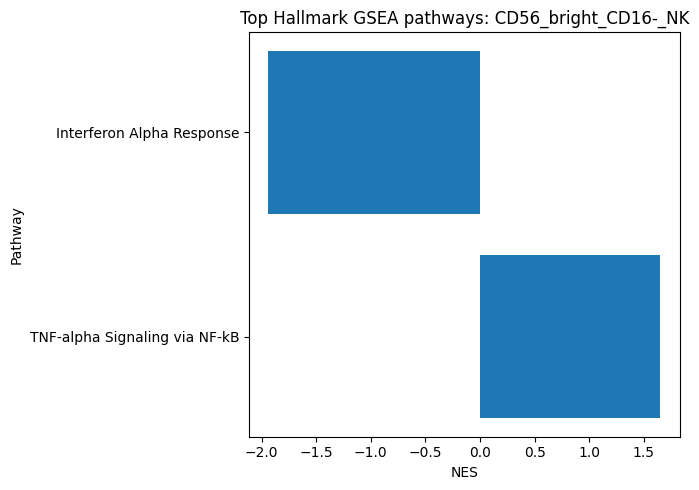

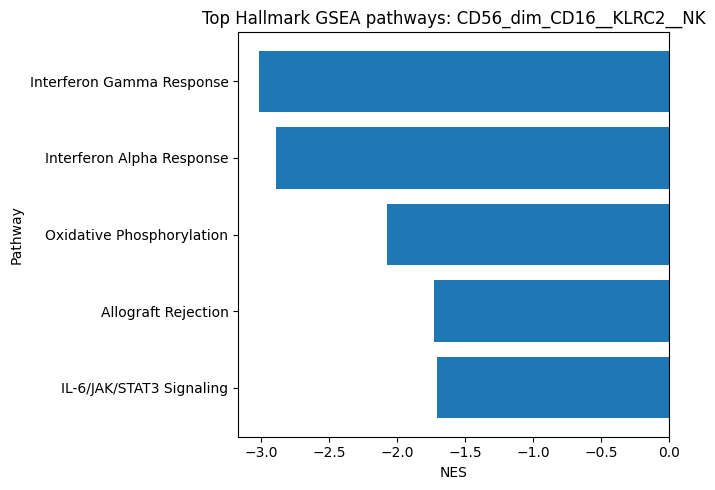

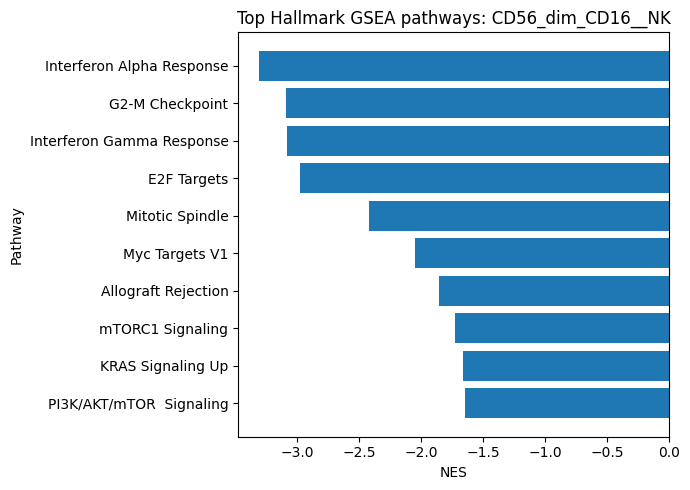

In [27]:
# Plot top GSEA pathways per cell type
for ct in gsea_summary["cell_type"].unique():
    
    df = gsea_summary[gsea_summary["cell_type"] == ct].copy()
    df = df.sort_values("FDR q-val").head(10)
    
    if df.empty:
        continue
    
    plt.figure(figsize=(7, 5))
    plt.barh(df["Term"], df["NES"])
    plt.xlabel("NES")
    plt.ylabel("Pathway")
    plt.title(f"Top Hallmark GSEA pathways: {ct}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    plt.savefig(outdir / f"GSEA_top_pathways_{ct}.png", dpi=300)
    plt.show()